# 18 — Question-Level Diagnostic: Where Human and Model Priors Converge and Diverge

**Goal:** Move beyond aggregate statistics to question-level case studies that reveal *why* human-model alignment varies. Identify diagnostic quadrants:
1. **Shared prior** — humans and models converge (high HH + high HM)
2. **Entity-anchor dependency** — alignment collapses under pronominalization (large C→A drop)
3. **Robust structural prior** — alignment persists without entity cues (small C→A drop)
4. **Model overconfidence** — models answer correctly, humans cannot (high model acc, low human acc)
5. **Vision encoder interference** — backbone decoder >> VLM on specific questions

Generates figures for the paper's question-level diagnostic section.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from collections import Counter

ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'analysis'))
from figures.helpers import save_fig
from utils.constants import GROUP_COLORS, GROUP_ORDER, VARIANT_ORDER, VARIANT_COLORS, VARIANT_LABELS
from config import MODELS_7B

EXPORTS = ROOT / 'analysis/session2/exports'
OUT_DIR = ROOT / 'analysis/session2/entropy/exports/figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

_7b = set(MODELS_7B)

In [2]:
# ── 1. Build per-question diagnostic table ──────────────────────────────────

pc = pd.read_parquet(EXPORTS / 'pair_cache_raw.parquet')
human = pd.read_csv(EXPORTS / 'responses_human.csv')
model_ib = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')

# Per-question HH / HM SBERT across variants
rows = []
for v in VARIANT_ORDER:
    sub = pc[pc['variant'] == v]
    hh = sub[sub['pair_type'] == 'HH'].groupby('question_id')['sbert_score'].mean()
    hm = sub[(sub['pair_type'] == 'HM') & (sub['subject_2'].isin(_7b))].groupby('question_id')['sbert_score'].mean()
    # HM by group
    hm_grp = sub[(sub['pair_type'] == 'HM') & (sub['subject_2'].isin(_7b))].groupby(
        ['question_id', 'subject_group_2'])['sbert_score'].mean().unstack()
    for qid in hh.index:
        row = {'question_id': qid, 'variant': v, 'hh_sbert': hh.get(qid, np.nan), 'hm_sbert': hm.get(qid, np.nan)}
        for g in GROUP_ORDER:
            if g in hm_grp.columns:
                row[f'hm_{g}'] = hm_grp[g].get(qid, np.nan)
        rows.append(row)

qv = pd.DataFrame(rows)

# Human / model accuracy (variant C)
h_acc = human[human['variant'] == 'C'].groupby('question_id')['accuracy'].mean().rename('human_acc')
m_acc = model_ib[(model_ib['variant'] == 'C') & (model_ib['model'].isin(_7b))].groupby('question_id')['accuracy'].mean().rename('model_acc')

# Question metadata
meta = human[human['variant'] == 'C'].drop_duplicates('question_id')[
    ['question_id', 'question_en', 'ent', 'op', 'gt']
].set_index('question_id')

# Pivot for C/B/A columns
qwide = qv.pivot(index='question_id', columns='variant', values=['hh_sbert', 'hm_sbert'])
qwide.columns = [f'{m}_{v}' for m, v in qwide.columns]

# Group-level pivots
for g in GROUP_ORDER:
    col = f'hm_{g}'
    if col in qv.columns:
        gpiv = qv.pivot(index='question_id', columns='variant', values=col)
        gpiv.columns = [f'{col}_{v}' for v in gpiv.columns]
        qwide = qwide.join(gpiv)

df = qwide.join(h_acc).join(m_acc).join(meta)
df['hm_drop_CA'] = df['hm_sbert_C'] - df['hm_sbert_A']
df['hh_hm_gap'] = df['hh_sbert_C'] - df['hm_sbert_C']

# Backbone - VLM gap
bb_col_C = 'hm_VLM backbone decoder_C'
vlm_col_C = 'hm_VLM_C'
if bb_col_C in df.columns and vlm_col_C in df.columns:
    df['bb_vlm_gap'] = df[bb_col_C] - df[vlm_col_C]

print(f'Diagnostic table: {len(df)} questions, {df.shape[1]} features')
print(f'HM SBERT C: mean={df.hm_sbert_C.mean():.3f}, std={df.hm_sbert_C.std():.3f}')
print(f'C→A drop:   mean={df.hm_drop_CA.mean():.3f}, std={df.hm_drop_CA.std():.3f}')
df.head(3)

Diagnostic table: 88 questions, 27 features
HM SBERT C: mean=0.460, std=0.146
C→A drop:   mean=0.076, std=0.109


,hh_sbert_A,hh_sbert_B,hh_sbert_C,hm_sbert_A,hm_sbert_B,hm_sbert_C,hm_VLM_A,hm_VLM_B,hm_VLM_C,hm_VLM backbone decoder_A,...,hm_standalone LLM (think)_C,human_acc,model_acc,question_en,ent,op,gt,hm_drop_CA,hh_hm_gap,bb_vlm_gap
question_id,,,,,,,,,,,,,,,,,,,,,
1342072,0.158418,0.167841,0.183090,0.191738,0.177682,0.192655,0.189587,0.200407,0.219156,0.195032,...,0.12060,0.000,0.041667,What kind of information does the yellow and w...,other,ident,on planes | airplane info | transportation inf...,0.000917,-0.009565,-0.010508
2521002,0.424941,0.426133,0.442022,0.316924,0.374172,0.406263,0.307204,0.348448,0.430794,0.357634,...,0.53675,0.350,0.208333,Which way is the arrow pointing?,object,spat,left | left | left | left | right | left | lef...,0.089338,0.035759,-0.055171
9830000,0.237986,0.230326,0.462199,0.200740,0.270686,0.516826,0.229988,0.281071,0.487467,0.203430,...,0.60446,0.275,0.625000,What type of computer is the cat using?,product,attr,macbook pro laptop | laptop | macbook | laptop...,0.316086,-0.054627,0.089021


Saved: /home/david/Desktop/yuna/HPA/analysis/session2/entropy/exports/figures/diagnostic_quadrant_scatter.png


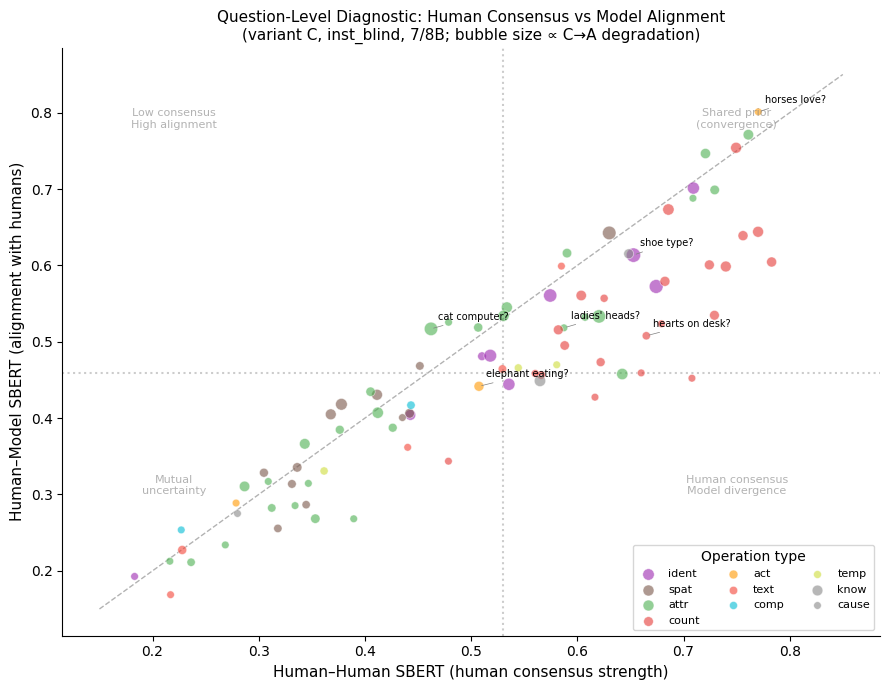

In [3]:
# ── 2. Figure: Diagnostic Quadrant Scatter ──────────────────────────────────
# X = HH SBERT (human consensus), Y = HM SBERT (human-model alignment)
# Color by operation type; size by C→A drop magnitude

OP_COLORS = {
    'yesno': '#2196F3', 'count': '#E53935', 'attr': '#4CAF50',
    'act': '#FF9800', 'ident': '#9C27B0', 'spat': '#795548',
    'wk': '#607D8B', 'comp': '#00BCD4', 'temp': '#CDDC39',
    'text': '#F44336', 'caus': '#3F51B5',
}

fig, ax = plt.subplots(figsize=(9, 7))

for op in df['op'].unique():
    sub = df[df['op'] == op]
    color = OP_COLORS.get(op, '#888')
    sizes = 30 + 200 * sub['hm_drop_CA'].clip(0, 0.4)
    ax.scatter(sub['hh_sbert_C'], sub['hm_sbert_C'], s=sizes,
               c=color, alpha=0.6, edgecolors='white', lw=0.5, label=op, zorder=3)

# Diagonal reference
lims = [0.15, 0.85]
ax.plot(lims, lims, 'k--', alpha=0.3, lw=1, zorder=1)

# Quadrant lines at medians
hh_med = df['hh_sbert_C'].median()
hm_med = df['hm_sbert_C'].median()
ax.axvline(hh_med, color='gray', ls=':', alpha=0.4)
ax.axhline(hm_med, color='gray', ls=':', alpha=0.4)

# Annotate key questions
annotations = {
    463588002: 'horses love?',
    90646004: 'shoe type?',
    164453003: 'hearts on desk?',
    9830000: 'cat computer?',
    140713012: 'elephant eating?',
    121839003: 'ladies\' heads?',
}
for qid, label in annotations.items():
    if qid in df.index:
        r = df.loc[qid]
        ax.annotate(label, (r.hh_sbert_C, r.hm_sbert_C),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(5, 5), textcoords='offset points',
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_xlabel('Human–Human SBERT (human consensus strength)', fontsize=11)
ax.set_ylabel('Human–Model SBERT (alignment with humans)', fontsize=11)
ax.set_title('Question-Level Diagnostic: Human Consensus vs Model Alignment\n'
             '(variant C, inst_blind, 7/8B; bubble size ∝ C→A degradation)', fontsize=11)
ax.legend(fontsize=8, ncol=3, loc='lower right', frameon=True, title='Operation type')
ax.spines[['top', 'right']].set_visible(False)

# Quadrant labels
ax.text(0.22, 0.78, 'Low consensus\nHigh alignment', fontsize=8, color='gray', alpha=0.6, ha='center')
ax.text(0.75, 0.78, 'Shared prior\n(convergence)', fontsize=8, color='gray', alpha=0.6, ha='center')
ax.text(0.22, 0.30, 'Mutual\nuncertainty', fontsize=8, color='gray', alpha=0.6, ha='center')
ax.text(0.75, 0.30, 'Human consensus\nModel divergence', fontsize=8, color='gray', alpha=0.6, ha='center')

plt.tight_layout()
save_fig(fig, OUT_DIR, 'diagnostic_quadrant_scatter.png')
plt.show()

Saved: /home/david/Desktop/yuna/HPA/analysis/session2/entropy/exports/figures/case_study_variant_trajectories.png


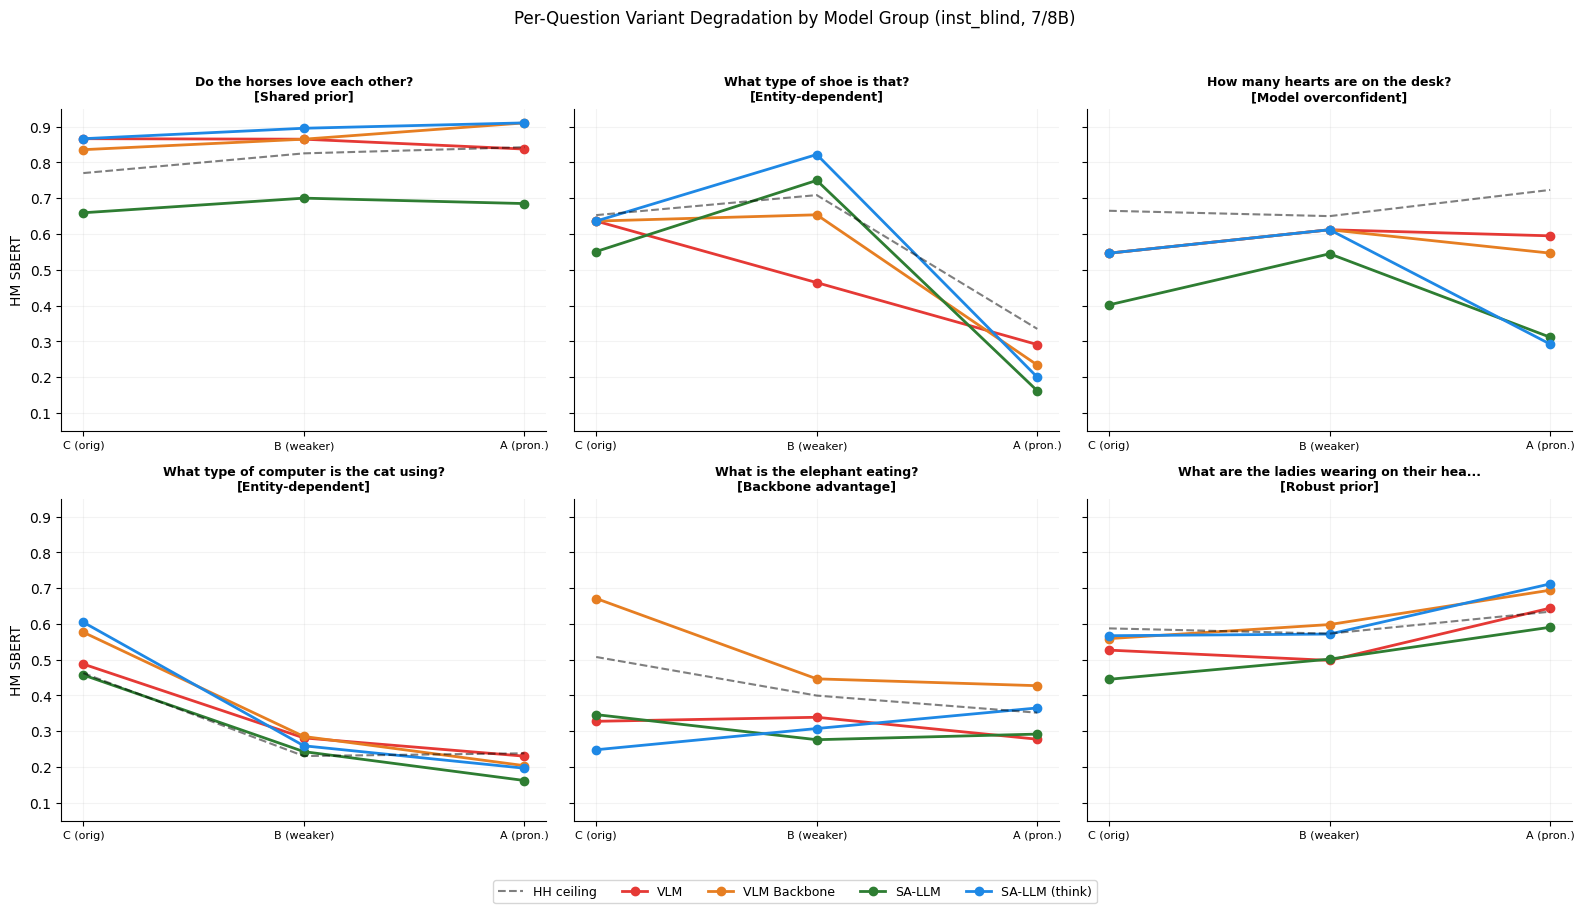

In [4]:
# ── 3. Figure: Case Study Panel — Variant Degradation Trajectories ──────────
# Show per-question HM SBERT trajectories C→B→A for selected case study questions
# Split by group to show backbone vs VLM vs SA-LLM

CASES = {
    # (qid, short_label, category)
    463588002: ('Do the horses love each other?', 'Shared prior'),
    90646004:  ('What type of shoe is that?', 'Entity-dependent'),
    164453003: ('How many hearts are on the desk?', 'Model overconfident'),
    9830000:   ('What type of computer is the cat using?', 'Entity-dependent'),
    140713012: ('What is the elephant eating?', 'Backbone advantage'),
    121839003: ('What are the ladies wearing on their heads?', 'Robust prior'),
}

# Get per-question, per-group, per-variant HM SBERT
case_data = qv[qv['question_id'].isin(CASES.keys())].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for idx, (qid, (q_text, category)) in enumerate(CASES.items()):
    ax = axes[idx]
    qsub = case_data[case_data['question_id'] == qid]

    # HH ceiling trajectory
    hh_vals = []
    for v in VARIANT_ORDER:
        val = qsub[qsub['variant'] == v]['hh_sbert'].values
        hh_vals.append(val[0] if len(val) else np.nan)
    ax.plot(range(3), hh_vals, 'k--', lw=1.5, alpha=0.5, label='HH ceiling', zorder=5)

    # Per-group trajectories
    for g in GROUP_ORDER:
        col = f'hm_{g}'
        if col not in qsub.columns:
            continue
        vals = []
        for v in VARIANT_ORDER:
            row = qsub[qsub['variant'] == v]
            vals.append(row[col].values[0] if len(row) and not pd.isna(row[col].values[0]) else np.nan)
        if all(np.isnan(v) for v in vals):
            continue
        color = GROUP_COLORS.get(g, '#888')
        label = g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'Backbone')
        ax.plot(range(3), vals, 'o-', color=color, lw=2, markersize=6, label=label, zorder=4)

    ax.set_xticks(range(3))
    ax.set_xticklabels(['C (orig)', 'B (weaker)', 'A (pron.)'], fontsize=8)
    ax.set_title(f'{q_text[:40]}...\n[{category}]' if len(q_text) > 40 else f'{q_text}\n[{category}]',
                 fontsize=9, fontweight='bold')
    ax.set_ylim(0.05, 0.95)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.15)

    if idx == 0:
        ax.set_ylabel('HM SBERT', fontsize=10)
    if idx == 3:
        ax.set_ylabel('HM SBERT', fontsize=10)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Per-Question Variant Degradation by Model Group (inst_blind, 7/8B)', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
save_fig(fig, OUT_DIR, 'case_study_variant_trajectories.png')
plt.show()

Saved: /home/david/Desktop/yuna/HPA/analysis/session2/entropy/exports/figures/case_study_answer_distributions.png


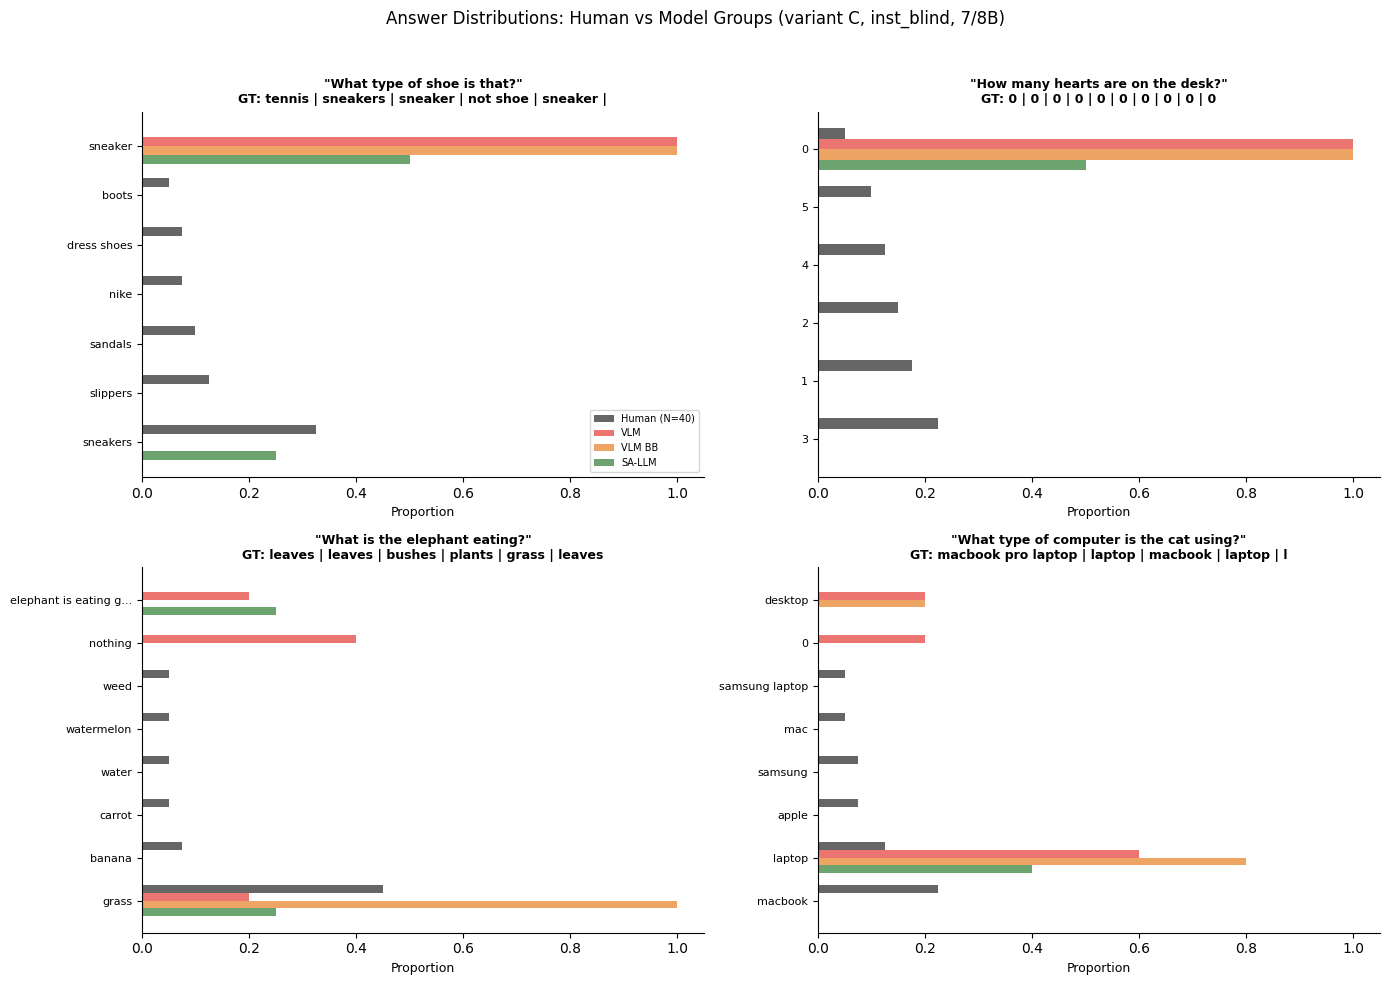

In [5]:
# ── 4. Figure: Answer Distribution Comparison (Human vs Model Groups) ───────
# For each case study question, show what humans answered vs what each model group answered

def get_top_answers(responses_df, qid, variant='C', group_col='model_group', answer_col='response', top_n=5):
    """Get top answers for a question, grouped."""
    sub = responses_df[(responses_df['question_id'] == qid) & (responses_df['variant'] == variant)]
    if group_col in sub.columns:
        return sub.groupby(group_col)[answer_col].apply(
            lambda x: x.value_counts().head(top_n).to_dict()
        ).to_dict()
    else:
        return {group_col: sub[answer_col].value_counts().head(top_n).to_dict()}

# Select 4 most informative cases for a compact figure
PANEL_CASES = [
    (90646004,  'What type of shoe is that?'),
    (164453003, 'How many hearts are on the desk?'),
    (140713012, 'What is the elephant eating?'),
    (9830000,   'What type of computer is the cat using?'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (qid, q_text) in enumerate(PANEL_CASES):
    ax = axes[idx]

    # Human answers
    h_sub = human[(human['question_id'] == qid) & (human['variant'] == 'C')]
    h_counts = h_sub['response'].value_counts().head(6)
    gt = h_sub['gt'].iloc[0][:50] if len(h_sub) else ''

    # Model answers by group (7B only)
    m_sub = model_ib[(model_ib['question_id'] == qid) & (model_ib['variant'] == 'C') & (model_ib['model'].isin(_7b))]

    # Collect all unique answers
    all_answers = list(h_counts.index[:6])
    for g in ['VLM', 'VLM backbone decoder', 'standalone LLM']:
        g_sub = m_sub[m_sub['model_group'] == g]
        for a in g_sub['response'].value_counts().head(3).index:
            if a not in all_answers and len(str(a)) < 25:
                all_answers.append(a)
    all_answers = all_answers[:8]  # limit

    # Build bars
    y = np.arange(len(all_answers))
    bar_h = 0.18

    # Human
    h_vals = [h_counts.get(a, 0) / len(h_sub) for a in all_answers]
    ax.barh(y + 1.5 * bar_h, h_vals, bar_h, color='black', alpha=0.6, label='Human (N=40)')

    # Model groups
    for gi, g in enumerate(['VLM', 'VLM backbone decoder', 'standalone LLM']):
        g_sub = m_sub[m_sub['model_group'] == g]
        g_counts = g_sub['response'].value_counts()
        g_total = len(g_sub)
        vals = [g_counts.get(a, 0) / g_total if g_total > 0 else 0 for a in all_answers]
        color = GROUP_COLORS.get(g, '#888')
        offset = (0.5 - gi) * bar_h
        label = g.replace('standalone LLM', 'SA-LLM').replace('backbone decoder', 'BB')
        ax.barh(y + offset, vals, bar_h, color=color, alpha=0.7, label=label)

    # Truncate long answer labels
    labels = [a[:20] + '...' if len(str(a)) > 20 else str(a) for a in all_answers]
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Proportion', fontsize=9)
    ax.set_title(f'"{q_text}"\nGT: {gt}', fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, 1.05)

    if idx == 0:
        ax.legend(fontsize=7, loc='lower right', frameon=True)

fig.suptitle('Answer Distributions: Human vs Model Groups (variant C, inst_blind, 7/8B)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, OUT_DIR, 'case_study_answer_distributions.png')
plt.show()

In [ ]:
# ── 5. Figure: Information-Theoretic View — Entropy vs Alignment ────────────
# For each question: compute answer entropy (human) and answer entropy (model)
# Higher entropy = more uncertainty. Compare with HM alignment.

from scipy.stats import entropy as sp_entropy

def answer_entropy(responses, answer_col='response'):
    """Compute Shannon entropy of answer distribution."""
    counts = responses[answer_col].value_counts()
    probs = counts / counts.sum()
    return sp_entropy(probs, base=2)

# Human entropy per question (variant C)
h_ent = human[human['variant'] == 'C'].groupby('question_id').apply(
    lambda x: answer_entropy(x)
).rename('human_entropy')

# Overall model entropy (all 7B models, variant C)
m_ent_all = model_ib[(model_ib['variant'] == 'C') & (model_ib['model'].isin(_7b))].groupby('question_id').apply(
    lambda x: answer_entropy(x)
).rename('model_entropy')

# Merge — only keep questions present in df (the 88 free-text subset)
ent_df = pd.DataFrame({'human_entropy': h_ent, 'model_entropy': m_ent_all}).join(
    df[['hm_sbert_C', 'hh_sbert_C', 'human_acc', 'model_acc', 'op', 'question_en', 'hm_drop_CA']]
)
# Drop rows with ANY NaN or inf in the columns we'll correlate
for c in ['human_entropy', 'model_entropy', 'hm_sbert_C', 'hm_drop_CA']:
    ent_df = ent_df[ent_df[c].notna() & np.isfinite(ent_df[c])]

ent_df['entropy_gap'] = ent_df['model_entropy'] - ent_df['human_entropy']
print(f'Entropy analysis: {len(ent_df)} questions after dropping NaN/inf')

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Human entropy vs Model entropy
ax = axes[0]
for op in sorted(ent_df['op'].unique()):
    sub = ent_df[ent_df['op'] == op]
    ax.scatter(sub['human_entropy'], sub['model_entropy'], s=30, alpha=0.6,
               color=OP_COLORS.get(op, '#888'), label=op, edgecolors='white', lw=0.3)
ax.plot([0, 4.5], [0, 4.5], 'k--', alpha=0.3)
ax.set_xlabel('Human answer entropy (bits)', fontsize=10)
ax.set_ylabel('Model answer entropy (bits)', fontsize=10)
ax.set_title('Answer Uncertainty:\nHuman vs Model', fontsize=10)
ax.legend(fontsize=6.5, ncol=2, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
r1, p1 = stats.pearsonr(ent_df['human_entropy'], ent_df['model_entropy'])
ax.text(0.95, 0.05, f'r={r1:.2f}, p={p1:.1e}', transform=ax.transAxes, fontsize=8, ha='right')

# Panel 2: Human entropy vs HM SBERT
ax = axes[1]
ax.scatter(ent_df['human_entropy'], ent_df['hm_sbert_C'], s=30, alpha=0.5, c='#555', edgecolors='white', lw=0.3)
ax.set_xlabel('Human answer entropy (bits)', fontsize=10)
ax.set_ylabel('HM SBERT (variant C)', fontsize=10)
ax.set_title('Human Uncertainty vs\nHuman-Model Alignment', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
r2, p2 = stats.pearsonr(ent_df['human_entropy'], ent_df['hm_sbert_C'])
ax.text(0.95, 0.05, f'r={r2:.2f}, p={p2:.1e}', transform=ax.transAxes, fontsize=8, ha='right')

# Panel 3: Entropy gap vs C→A drop
ax = axes[2]
valid = ent_df[ent_df['entropy_gap'].notna() & ent_df['hm_drop_CA'].notna()]
ax.scatter(valid['entropy_gap'], valid['hm_drop_CA'], s=30, alpha=0.5, c='#555', edgecolors='white', lw=0.3)
ax.set_xlabel('Entropy gap (model − human, bits)', fontsize=10)
ax.set_ylabel('C→A degradation (SBERT)', fontsize=10)
ax.set_title('Entropy Mismatch vs\nEntity-Anchor Dependency', fontsize=10)
ax.axvline(0, color='gray', ls=':', alpha=0.3)
ax.axhline(0, color='gray', ls=':', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
if len(valid) > 2:
    r3, p3 = stats.pearsonr(valid['entropy_gap'], valid['hm_drop_CA'])
    ax.text(0.95, 0.05, f'r={r3:.2f}, p={p3:.1e}', transform=ax.transAxes, fontsize=8, ha='right')
else:
    r3 = float('nan')

plt.suptitle('Information-Theoretic View: Answer Entropy and Prior Alignment (7/8B, vC)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, OUT_DIR, 'entropy_alignment_analysis.png')
plt.show()

print(f'Human entropy: mean={ent_df.human_entropy.mean():.2f}, std={ent_df.human_entropy.std():.2f}')
print(f'Model entropy: mean={ent_df.model_entropy.mean():.2f}, std={ent_df.model_entropy.std():.2f}')
print(f'r(human_ent, model_ent) = {r1:.3f}')
print(f'r(human_ent, HM_SBERT)  = {r2:.3f}')
print(f'r(entropy_gap, CA_drop) = {r3:.3f}')

In [ ]:
# ── 6. Figure: Vision Encoder Interference — Per-Question BB vs VLM ─────────
# Dumbbell chart showing backbone decoder advantage per question

bb_col = 'hm_VLM backbone decoder_C'
vlm_col = 'hm_VLM_C'

if bb_col in df.columns and vlm_col in df.columns:
    plot_df = df[[bb_col, vlm_col, 'op', 'question_en', 'hm_drop_CA']].dropna().copy()
    plot_df['gap'] = plot_df[bb_col] - plot_df[vlm_col]
    plot_df = plot_df.sort_values('gap', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 12))
    y = np.arange(len(plot_df))

    for i, (qid, r) in enumerate(plot_df.iterrows()):
        color = '#E67E22' if r['gap'] > 0 else '#E53935'
        ax.plot([r[vlm_col], r[bb_col]], [i, i], color=color, lw=1.5, alpha=0.7)
        ax.scatter(r[vlm_col], i, color='#E53935', s=25, zorder=5, edgecolors='white', lw=0.3)
        ax.scatter(r[bb_col], i, color='#E67E22', s=25, zorder=5, edgecolors='white', lw=0.3)

    # Labels
    q_labels = [f'{str(r.question_en)[:35]}... [{r.op}]' if len(str(r.question_en)) > 35
                else f'{r.question_en} [{r.op}]' for _, r in plot_df.iterrows()]
    ax.set_yticks(y)
    ax.set_yticklabels(q_labels, fontsize=6.5)
    ax.set_xlabel('HM SBERT (variant C)', fontsize=10)
    ax.set_title('Per-Question Vision Encoder Effect:\nBackbone Decoder (orange) vs VLM (red)', fontsize=11)
    ax.axvline(plot_df[bb_col].mean(), color='#E67E22', ls='--', alpha=0.4, lw=1)
    ax.axvline(plot_df[vlm_col].mean(), color='#E53935', ls='--', alpha=0.4, lw=1)
    ax.spines[['top', 'right']].set_visible(False)

    # Summary stats
    n_bb_wins = (plot_df['gap'] > 0).sum()
    n_total = len(plot_df)
    ax.text(0.02, 0.02, f'Backbone > VLM on {n_bb_wins}/{n_total} questions ({100*n_bb_wins/n_total:.0f}%)',
            transform=ax.transAxes, fontsize=9, va='bottom')

    plt.tight_layout()
    save_fig(fig, OUT_DIR, 'backbone_vlm_dumbbell_per_question.png')
    plt.show()

    print(f'Backbone > VLM: {n_bb_wins}/{n_total} ({100*n_bb_wins/n_total:.0f}%)')
    print(f'Mean gap: {plot_df.gap.mean():.3f} (positive = backbone wins)')
else:
    print('Missing group columns — check pair_cache')

In [ ]:
# ── 7. Summary Table for LaTeX — Case Study Questions ───────────────────────
# Print a LaTeX-ready table of case study questions with key metrics

case_qids = [463588002, 90646004, 164453003, 9830000, 140713012, 121839003]
case_labels = ['Shared prior', 'Entity-dependent', 'Overconfident', 'Entity-dependent', 'BB advantage', 'Robust prior']

print(r'\begin{table*}[t]')
print(r'\centering')
print(r'\caption{Question-level diagnostic case studies. HH/HM = mean pairwise SBERT cosine;')
print(r'$\Delta_{C\to A}$ = HM degradation under pronominalization; BB$-$VLM = backbone advantage.}')
print(r'\label{tab:case_study}')
print(r'\small')
print(r'\setlength{\tabcolsep}{4pt}')
print(r'\begin{tabular}{p{3.8cm}lcccccc}')
print(r'\toprule')
print(r'\textbf{Question} & \textbf{Type} & \textbf{HH} & \textbf{HM} & \textbf{h(q)} & \textbf{m(q)} & \textbf{$\Delta_{C\to A}$} & \textbf{BB$-$VLM} \\')
print(r'\midrule')

for qid, label in zip(case_qids, case_labels):
    if qid not in df.index:
        continue
    r = df.loc[qid]
    q_short = str(r.question_en)[:38]
    if len(str(r.question_en)) > 38:
        q_short += '...'
    bb_vlm = r.get('bb_vlm_gap', float('nan'))
    bb_str = f'{bb_vlm:+.3f}' if not pd.isna(bb_vlm) else '--'
    print(f'{q_short} & {label} & {r.hh_sbert_C:.3f} & {r.hm_sbert_C:.3f} & '
          f'{r.human_acc:.2f} & {r.model_acc:.2f} & {r.hm_drop_CA:+.3f} & {bb_str} \\\\')

print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table*}')

# Also print human & model top answers for each
print('\n\n% ── Answer distributions for case study narratives ──')
for qid in case_qids:
    h_sub = human[(human['question_id']==qid)&(human['variant']=='C')]
    m_sub = model_ib[(model_ib['question_id']==qid)&(model_ib['variant']=='C')&(model_ib['model'].isin(_7b))]
    q = h_sub['question_en'].iloc[0] if len(h_sub) else '?'
    gt = str(h_sub['gt'].iloc[0])[:40] if len(h_sub) else '?'

    h_top = h_sub['response'].value_counts().head(3)
    m_top = m_sub['response'].value_counts().head(3)

    print(f'\n% QID {qid}: "{q}"')
    print(f'% GT: {gt}')
    print(f'% Human top: {dict(h_top)}')
    print(f'% Model top: {dict(m_top)}')